In [1]:
#!/usr/bin/env python
# coding: utf-8

import os
import numpy as np
import numpy as np
import MDAnalysis as mda
from nmrdfrommd import NMRD
from concurrent.futures import ProcessPoolExecutor, as_completed

from utilities import save_result, get_git_repo_path

/home/simon/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
git_path = get_git_repo_path()

In [8]:
n = 1
T = 3.4

data_dir = os.path.join(git_path, "data", "varying-temperature", f"T{T}")
topology_file = os.path.join(data_dir, "topology.data")
trajectory_file = os.path.join(data_dir, "dump"+str(n)+".xtc")

u = mda.Universe(topology_file, trajectory_file)

all_atoms = u.select_atoms("all")
n_atoms = all_atoms.n_atoms
number_i = 1 # np.min([n_atoms, 500])

nmr = NMRD(
    u=u,
    atom_group=all_atoms,
    number_i=number_i)
nmr.run_analysis()

{'gij': array([[ 7.2027445e-03,  6.6374750e-03,  5.8088223e-03, ...,
         -4.6959372e-05, -4.8623191e-05, -5.9909689e-05]],
       shape=(1, 10001), dtype=float32),
 'R1_mean': array([2.46431166e-03, 2.58573508e-03, 2.64084434e-03, ...,
        2.92614989e-05, 2.92495842e-05, 2.92216043e-05], shape=(5001,)),
 'R1_M2': array([0., 0., 0., ..., 0., 0., 0.], shape=(5001,)),
 'R2_mean': array([0.00246431, 0.00257344, 0.00255705, ..., 0.00078772, 0.00078774,
        0.00078773], shape=(5001,)),
 'R2_M2': array([0., 0., 0., ..., 0., 0., 0.], shape=(5001,)),
 't': array([0.000000e+00, 2.320000e-02, 4.640000e-02, ..., 2.319536e+02,
        2.319768e+02, 2.320000e+02], shape=(10001,)),
 'f': array([0.00000000e+00, 4.30991384e+03, 8.61982767e+03, ...,
        2.15409494e+07, 2.15452593e+07, 2.15495692e+07], shape=(5001,)),
 'J': array([[4.61522768e-15, 4.94306043e-15, 4.81752571e-15, ...,
         1.71082568e-16, 1.71203893e-16, 1.71174781e-16]], shape=(1, 5001)),
 'R1': array([2.46431166e-03

In [9]:
import matplotlib.pyplot as plt

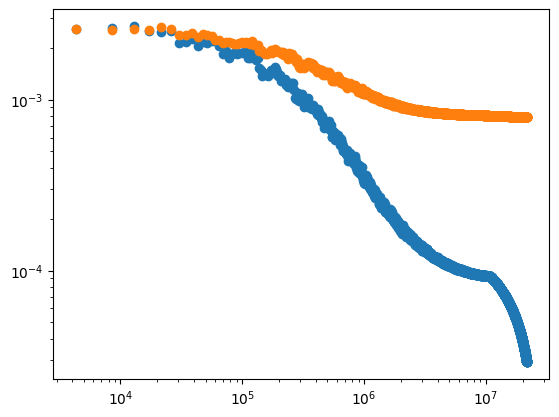

In [10]:
f = nmr.results["f"]
R1 = nmr.results["R1"]
R2 = nmr.results["R2"]

plt.loglog(f, R1, "o")
plt.loglog(f, R2, "o")

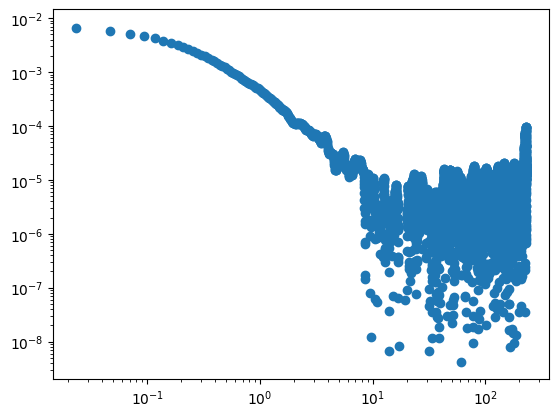

In [12]:
t = nmr.results["t"]
gij = nmr.results["gij"][0]

plt.loglog(t, gij, "o")

In [13]:
nmr.results

{'gij': array([[0.00661568, 0.00645204, 0.00612488, ..., 0.00010251, 0.00011661,
         0.00012608]], shape=(1, 10001), dtype=float32),
 't': array([0.000000e+00, 2.320000e-02, 4.640000e-02, ..., 2.319536e+02,
        2.319768e+02, 2.320000e+02], shape=(10001,)),
 'J': array([[1.79505216e-14, 1.93829137e-14, 1.77595618e-14, ...,
         1.50546226e-16, 1.50546425e-16, 1.50551765e-16]], shape=(1, 5001)),
 'f': array([0.00000000e+00, 4.30991384e+03, 8.61982767e+03, ...,
        2.15409494e+07, 2.15452593e+07, 2.15495692e+07], shape=(5001,)),
 'R1': array([9.58472318e-03, 9.65611822e-03, 8.88175795e-03, ...,
        9.17837412e-05, 9.17883248e-05, 9.17934575e-05], shape=(5001,)),
 'R2': array([0.00958472, 0.00994675, 0.0093631 , ..., 0.00293454, 0.00293454,
        0.00293454], shape=(5001,)),
 'T1': np.float64(104.33269500331252),
 'T2': np.float64(104.33269500331252)}

In [ ]:



def main(max_iterations):
    git_path = get_git_repo_path()
    all_T = ["0.8", "1.0", "1.2", "1.5", "1.8", "2.2", "2.6", "3.0"]
    all_N = np.arange(1, 11)
    for iteration in range(max_iterations):
        print(f"\n--- Iteration {iteration + 1} ---")
        with ProcessPoolExecutor(max_workers=10) as executor:
            futures = [executor.submit(process, T, n, git_path)
                       for T in all_T
                       for n in all_N]
            for future in as_completed(futures):
                future.result()

if __name__ == "__main__":
    main(max_iterations=1)